In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/retail-store-product-sales-simulation-dataset/RetailStoreProductSalesDataset.csv


In [2]:
import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = "/kaggle/input/retail-store-product-sales-simulation-dataset/RetailStoreProductSalesDataset.csv"
df = pd.read_csv(data)
df.head(5)

,Unnamed: 0,price,discount,promotion_intensity,footfall,ad_spend,competitor_price,stock_level,weather_index,customer_sentiment,return_rate
0,0,45.197454,5.514259,4.062653,277.017484,2559.073870,44.255411,1176.981397,7.442194,1.021762,0.067388
1,1,49.327512,6.572035,4.964657,250.760714,2536.417155,50.331704,1219.359497,6.759510,0.975142,0.082719
2,2,47.328457,6.972713,4.363191,263.130478,2552.952356,49.285996,1263.822738,5.941689,0.871567,0.061600
3,3,50.964538,4.808234,3.577988,297.603918,2605.398826,46.839936,1182.435378,8.517014,1.071300,0.052215
4,4,44.530213,8.180216,4.966638,208.931691,2432.485683,45.336500,1178.513263,8.422473,1.068515,0.057975


In [3]:
df.shape

(15000, 11)

In [4]:
corr_return_rate = df.corr()['return_rate'].sort_values(ascending = False)
corr_return_rate

return_rate            1.000000
ad_spend               0.124195
Unnamed: 0             0.055581
footfall               0.052372
stock_level            0.044732
discount              -0.047649
promotion_intensity   -0.062459
weather_index         -0.300116
competitor_price      -0.357296
price                 -0.366146
customer_sentiment    -0.673464
Name: return_rate, dtype: float64

In [5]:
data = df.drop(columns=['return_rate'])
y = df['return_rate']

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(data,y, test_size = 0.2,random_state=42)

In [7]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [8]:
import tensorflow
from tensorflow import keras
from keras import layers
from keras.layers import Dense,Dropout
from keras import Sequential

2026-01-24 09:22:48.763924: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769246568.966187      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769246569.023845      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769246569.534559      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769246569.534622      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769246569.534625      17 computation_placer.cc:177] computation placer alr

In [9]:
model = Sequential()
model.add(Dense(10, input_dim = 10,activation = 'relu',kernel_initializer = 'he_normal'))
model.add(Dropout(0.3))
model.add(Dense(4,activation='relu',kernel_initializer = 'he_normal'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='linear',kernel_initializer = 'he_normal'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-24 09:23:02.582930: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
model.get_weights()

[array([[-0.44653812, -0.8668545 , -0.22802515, -0.7719843 ,  0.15605631,
         -0.63474864,  0.2960403 ,  0.174657  ,  0.3387315 , -0.01015874],
        [-0.34814814,  0.38711125, -0.17954318,  0.6361721 , -0.07736067,
          0.356888  ,  0.4797359 ,  0.90324134,  0.34414327, -0.20929785],
        [ 0.33362952,  0.31124976,  0.16566578, -0.3152362 , -0.18823303,
          0.07621824,  0.04583708, -0.08531965,  0.37677792,  0.47257164],
        [-0.5367371 ,  0.5965095 ,  0.35243395, -0.16776872,  0.08945897,
         -0.6076137 ,  0.02027396, -0.12957408,  0.2284341 ,  0.23583543],
        [ 0.29308298, -0.64270025,  0.2673367 , -0.6463128 , -0.27090424,
         -0.67226803,  0.66395634, -0.07479956,  0.24881835, -0.35132977],
        [ 0.13054697,  0.08723803, -0.80924886,  0.7646017 ,  0.38517624,
          0.09246017,  0.2503242 ,  0.1175973 ,  0.00533141, -0.6176961 ],
        [ 0.21832336, -0.05166928, -0.30614942,  0.24627797,  0.3625278 ,
         -0.42673513,  0.3408520

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            44 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159 (636.00 B)

 Trainable params: 159 (636.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(X_train_scaled, y_train, epochs=40, batch_size=8,validation_split=0.2)

Epoch 1/40
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4852 - mae: 0.3385 - val_loss: 8.8244e-04 - val_mae: 0.0220
Epoch 2/40
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0103 - mae: 0.0326 - val_loss: 3.0676e-04 - val_mae: 0.0136
Epoch 3/40
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0022 - mae: 0.0165 - val_loss: 3.0467e-04 - val_mae: 0.0136
Epoch 4/40
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.5941e-04 - mae: 0.0149 - val_loss: 3.0510e-04 - val_mae: 0.0137
Epoch 5/40
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.3887e-04 - mae: 0.0144 - val_loss: 3.0635e-04 - val_mae: 0.0137
Epoch 6/40
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.6318e-04 - mae: 0.0137 - val_loss: 2.9842e-04 - val_mae: 0.0135
Epoch 7/40
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.9788e-04 - mae: 0.0140 - val_loss: 2.8869e-04 - val_mae: 0.0133
Epoch 8/40
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.2737e-04 - mae: 0.0136 - val_loss: 2.9909e-04 - val_

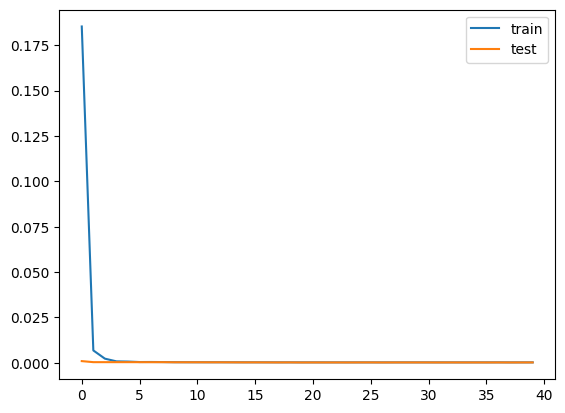

In [13]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

In [14]:
y_pred = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [15]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mse

19.778244037669783

In [16]:
y_pred[0]

array([0.06150096], dtype=float32)

In [17]:
y_test.iloc[0]

np.float64(0.0615395465074)